In [2]:
# ============================================================================
# Imports
# ============================================================================

import gc
import json
import numpy as np
import pandas as pd
from types import SimpleNamespace
from collections import defaultdict
from tqdm import tqdm

from verbatim_rag.extractors import LLMSpanExtractor, SemanticHighlightExtractor

import os
os.makedirs('phase2_results', exist_ok=True)

In [3]:
import json

def load_jsonl(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        return [json.loads(line) for line in f]

dev_answerable = load_jsonl('../../data/clapnq_dev_answerable.jsonl')
dev_unanswerable = load_jsonl('../../data/clapnq_dev_unanswerable.jsonl')

print(f"Answerable: {len(dev_answerable)}")
print(f"Unanswerable: {len(dev_unanswerable)}")

Answerable: 300
Unanswerable: 300


In [6]:
# ============================================================================
# IoU and Evaluation Functions
# ============================================================================

def find_span_in_passage(span: str, passage: str) -> tuple[int, int] | None:
    """
    Find the character-level start and end position of a span in the passage.
    Returns (start, end) or None if not found.
    """
    # Try exact match first
    idx = passage.find(span)
    if idx != -1:
        return (idx, idx + len(span))
    
    # Try stripped match
    span_stripped = span.strip()
    idx = passage.find(span_stripped)
    if idx != -1:
        return (idx, idx + len(span_stripped))
    
    return None


def compute_char_iou(range_a: tuple[int, int], range_b: tuple[int, int]) -> float:
    """
    Compute Intersection-over-Union for two character ranges.
    Each range is (start, end) where end is exclusive.
    """
    inter_start = max(range_a[0], range_b[0])
    inter_end = min(range_a[1], range_b[1])
    intersection = max(0, inter_end - inter_start)
    
    union = (range_a[1] - range_a[0]) + (range_b[1] - range_b[0]) - intersection
    
    if union == 0:
        return 0.0
    return intersection / union



# ============================================================================
# Additional Metrics: Token-F1, Coverage, Over-Extraction
# ============================================================================

def tokenize_simple(text: str) -> list[str]:
    """Simple whitespace + punctuation tokenizer for Token-F1."""
    import re
    return re.findall(r'\w+', text.lower())


def compute_token_f1(extracted_spans: list[str], gt_sentences: list[str]) -> dict:
    """
    Compute Token-level Precision, Recall, F1 (SQuAD-style).
    
    Tokenizes all extracted spans and all GT sentences,
    then computes overlap on the token multisets.
    
    Reference: Rajpurkar et al. (2016), SQuAD.
    """
    # Collect all tokens from extracted spans
    pred_tokens = []
    for span in extracted_spans:
        pred_tokens.extend(tokenize_simple(span))
    
    # Collect all tokens from GT sentences
    gt_tokens = []
    for sent in gt_sentences:
        gt_tokens.extend(tokenize_simple(sent))
    
    if not pred_tokens and not gt_tokens:
        return {'token_precision': 1.0, 'token_recall': 1.0, 'token_f1': 1.0}
    if not pred_tokens:
        return {'token_precision': 0.0, 'token_recall': 0.0, 'token_f1': 0.0}
    if not gt_tokens:
        return {'token_precision': 0.0, 'token_recall': 0.0, 'token_f1': 0.0}
    
    # Count overlapping tokens (multiset intersection)
    from collections import Counter
    pred_counts = Counter(pred_tokens)
    gt_counts = Counter(gt_tokens)
    
    overlap = 0
    for token, count in pred_counts.items():
        overlap += min(count, gt_counts.get(token, 0))
    
    precision = overlap / len(pred_tokens)
    recall = overlap / len(gt_tokens)
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {
        'token_precision': precision,
        'token_recall': recall,
        'token_f1': f1,
    }

def compute_span_iou_metrics(extracted_spans: list[str], 
                              gt_sentences: list[str], 
                              passage_text: str) -> dict:
    """
    Compute IoU between the combined extracted spans and the combined GT sentences.
    
    Instead of per-span vs. nearest GT sentence, this computes a single IoU
    per example by treating all GT sentences as one region and all extracted
    spans as another region, using character-level set overlap.
    """
    # Build character-level set for GT
    gt_chars = set()
    gt_ranges = []
    for sent in gt_sentences:
        pos = find_span_in_passage(sent, passage_text)
        if pos is not None:
            gt_ranges.append(pos)
            gt_chars.update(range(pos[0], pos[1]))
    
    # Build character-level set for extracted spans
    extracted_chars = set()
    extracted_ranges = []
    n_found = 0
    for span in extracted_spans:
        pos = find_span_in_passage(span, passage_text)
        if pos is not None:
            extracted_ranges.append(pos)
            extracted_chars.update(range(pos[0], pos[1]))
            n_found += 1
    
    # Compute IoU on character sets
    if not gt_chars and not extracted_chars:
        iou = 1.0  # both empty = perfect match
    elif not gt_chars or not extracted_chars:
        iou = 0.0  # one empty, one not
    else:
        intersection = len(gt_chars & extracted_chars)
        union = len(gt_chars | extracted_chars)
        iou = intersection / union
    
    return {
        'iou': iou,
        'n_extracted': len(extracted_spans),
        'n_extracted_found': n_found,
        'n_gt': len(gt_sentences),
        'n_gt_found': len(gt_ranges),
        'gt_chars': len(gt_chars),
        'extracted_chars': len(extracted_chars),
        'intersection_chars': len(gt_chars & extracted_chars) if gt_chars and extracted_chars else 0,
    }


def compute_coverage_and_overextraction(extracted_spans: list[str],
                                         gt_sentences: list[str],
                                         passage_text: str) -> dict:
    """
    Compute character-level Coverage and Over-Extraction.
    
    Coverage: fraction of GT character positions covered by any extracted span.
    Over-Extraction: fraction of extracted characters that fall outside all GT sentences.
    """
    # Build GT character set
    gt_char_set = set()
    for sent in gt_sentences:
        pos = find_span_in_passage(sent, passage_text)
        if pos is not None:
            gt_char_set.update(range(pos[0], pos[1]))
    
    # Build extracted character set
    pred_char_set = set()
    for span in extracted_spans:
        pos = find_span_in_passage(span, passage_text)
        if pos is not None:
            pred_char_set.update(range(pos[0], pos[1]))
    
    if not gt_char_set and not pred_char_set:
        return {'coverage': 1.0, 'over_extraction': 0.0}
    
    # Coverage: how much of GT is covered?
    if gt_char_set:
        intersection = gt_char_set & pred_char_set
        coverage = len(intersection) / len(gt_char_set)
    else:
        coverage = 0.0
    
    # Over-Extraction: how much of extracted is outside GT?
    if pred_char_set:
        outside_gt = pred_char_set - gt_char_set
        over_extraction = len(outside_gt) / len(pred_char_set)
    else:
        over_extraction = 0.0
    
    return {
        'coverage': coverage,
        'over_extraction': over_extraction,
    }


print("✅ Evaluation functions defined.")

✅ Evaluation functions defined.


In [4]:
# ============================================================================
# Quick Sanity Check on Example 0
# ============================================================================

ex = dev_answerable[0]
passage_text = ex['passages'][0]['text']
all_sents = ex['passages'][0]['sentences']
gt_sents = ex['output'][0]['selected_sentences']

# Test with a manually defined span (the LLM output from earlier)
test_spans_llm = [
    "forecasting procedure calculates the seasonal index of the `` season '' -- seven seasons , one for each day -- which is the ratio of the average demand of that season ( which is calculated by Moving Average or Exponential Smoothing using historical data corresponding only to that season ) to the average demand across all seas"
]
test_spans_sem = [
    "In such situations , the forecasting procedure calculates the seasonal index of the `` season '' -- seven seasons , one for each day -- which is the ratio of the average demand of that season ( which is calculated by Moving Average or Exponential Smoothing using historical data corresponding only to that season ) to the average demand across all seasons ."
]

print("=== LLM Span (manual test) ===")
iou_result = compute_span_iou_metrics(test_spans_llm, gt_sents, passage_text)
print(f"  IoU: {iou_result['iou']:.3f}")

print("\n=== Semantic Span (manual test) ===")
iou_result = compute_span_iou_metrics(test_spans_sem, gt_sents, passage_text)
print(f"  IoU: {iou_result['iou']:.3f}")



=== LLM Span (manual test) ===
  IoU: 0.521

=== Semantic Span (manual test) ===
  IoU: 0.568


In [7]:
# ============================================================================
# Run Extraction on Gold Passages (Both Extractors)
# ============================================================================
# 
# IMPORTANT: We run extractors on the GOLD PASSAGE, not via retrieval.
# This isolates extraction quality from retrieval errors.
#
# This cell takes a while — results are saved to JSON after each batch.
# If interrupted, you can reload from the JSON and continue.
# ============================================================================

def run_extraction_on_gold(dev_data, extractor, extractor_name, 
                           batch_size=50, save_path=None):
    """
    Run an extractor on gold passages for all examples.
    Returns list of dicts with extracted spans and metadata.
    """
    results = []
    save_path = save_path or f'phase2_{extractor_name}_spans.json'
    
    for batch_start in range(0, len(dev_data), batch_size):
        batch_end = min(batch_start + batch_size, len(dev_data))
        batch = dev_data[batch_start:batch_end]
        print(f"\n--- {extractor_name}: Batch {batch_start}-{batch_end} / {len(dev_data)} ---")
        
        for i, example in enumerate(tqdm(batch, desc=f"Extracting")):
            question = example['input']
            passage = example['passages'][0]
            passage_text = passage['text']
            
            search_results = [SimpleNamespace(text=passage_text)]
            
            try:
                spans_dict = extractor.extract_spans(question, search_results)
                extracted_spans = list(spans_dict.values())[0] if spans_dict else []
            except Exception as e:
                print(f"  Error on example {batch_start + i}: {e}")
                extracted_spans = []
            
            results.append({
                'id': example['id'],
                'question': question,
                'extracted_spans': extracted_spans,
                'gt_sentences': example['output'][0]['selected_sentences'],
                'all_sentences': passage['sentences'],
                'passage_text': passage_text,
            })
        
        # Save intermediate results
        with open(save_path, 'w') as f:
            json.dump(results, f, indent=2, ensure_ascii=False)
        print(f"  Saved {len(results)} results to {save_path}")
        
        gc.collect()
    
    return results

print("✅ Extraction runner defined.")

✅ Extraction runner defined.


In [11]:
llm_extractor = LLMSpanExtractor(span_match_mode="fuzzy")

In [ ]:
# ============================================================================
# LLMSpanExtractor - Run on Gold Passages
# ============================================================================

llm_results = run_extraction_on_gold(
    dev_answerable,   # <-- oder dev_answerable[:10] zum Testen
    llm_extractor, 
    extractor_name="llm_span",
    save_path="phase2_results/phase2_llm_span_results.json"
)

print(f"\n✅ LLMSpanExtractor done: {len(llm_results)} examples")


--- llm_span: Batch 0-50 / 300 ---


Extracting: 100%|██████████| 50/50 [01:47<00:00,  2.15s/it]


  Saved 50 results to phase2_results/phase2_llm_span_results.json

--- llm_span: Batch 50-100 / 300 ---


Extracting: 100%|██████████| 50/50 [05:57<00:00,  7.16s/it]  


  Saved 100 results to phase2_results/phase2_llm_span_results.json

--- llm_span: Batch 100-150 / 300 ---


...

  Saved 200 results to phase2_results/phase2_llm_span_results.json

--- llm_span: Batch 200-250 / 300 ---


Extracting: 100%|██████████| 50/50 [01:30<00:00,  1.81s/it]


  Saved 250 results to phase2_results/phase2_llm_span_results.json

--- llm_span: Batch 250-300 / 300 ---


Extracting: 100%|██████████| 50/50 [01:40<00:00,  2.01s/it]


  Saved 300 results to phase2_results/phase2_llm_span_results.json

✅ LLMSpanExtractor done: 300 examples


In [12]:
semantic_extractor = SemanticHighlightExtractor(
    threshold=0.5,
    output_mode="sentences",
)

In [ ]:
# ============================================================================
# SemanticHighlightExtractor - Run on Gold Passages
# ============================================================================

semantic_results = run_extraction_on_gold(
    dev_answerable,   # <-- oder dev_answerable[:10] zum Testen
    semantic_extractor, 
    extractor_name="semantic_highlight",
    save_path="phase2_results/phase2_semantic_highlight_results.json"
)

print(f"\n✅ SemanticHighlightExtractor done: {len(semantic_results)} examples")


--- semantic_highlight: Batch 0-50 / 300 ---


Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 62.15it/s]


[OpenProvenceModel] Model inference time: 9.77s (1 blocks)


Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 299.40it/s]


[OpenProvenceModel] Model inference time: 1.31s (1 blocks)


...

Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 404.97it/s]


[OpenProvenceModel] Model inference time: 0.59s (1 blocks)


Extracting: 100%|██████████| 50/50 [00:53<00:00,  1.06s/it]

  Saved 300 results to phase2_results/phase2_semantic_highlight_results.json



✅ SemanticHighlightExtractor done: 300 examples


In [5]:
# ============================================================================
# (Optional) Reload from saved JSON if session was interrupted
# ============================================================================

# Uncomment these lines if you need to reload:
with open('phase2_results/phase2_llm_span_results.json') as f:
    llm_results = json.load(f)
with open('phase2_results/phase2_semantic_highlight_results.json') as f:
    semantic_results = json.load(f)
print(f"Loaded: LLM={len(llm_results)}, Semantic={len(semantic_results)}")

Loaded: LLM=300, Semantic=300


In [8]:
# ============================================================================
# Compute All Metrics for Both Extractors
# ============================================================================

def evaluate_extractor(results: list[dict], name: str) -> dict:
    """
    Compute all Phase 2 metrics for one extractor's results.
    """
    all_ious = []
    all_token_f1s = []
    all_token_precisions = []
    all_token_recalls = []
    all_coverages = []
    all_over_extractions = []
    n_empty_extractions = 0
    n_total_gt_sentences = 0
    n_total_extracted_spans = 0
    
    for res in results:
        extracted = res['extracted_spans']
        gt_sents = res['gt_sentences']
        all_sents = res['all_sentences']
        passage = res['passage_text']
        
        n_total_gt_sentences += len(gt_sents)
        n_total_extracted_spans += len(extracted)
        
        if not extracted:
            n_empty_extractions += 1
            all_token_f1s.append(0.0)
            all_token_precisions.append(0.0)
            all_token_recalls.append(0.0)
            all_coverages.append(0.0)
            all_over_extractions.append(0.0)
            continue
        
        # IoU per example (combined extracted vs. combined GT)
        iou_result = compute_span_iou_metrics(extracted, gt_sents, passage)
        all_ious.append(iou_result['iou'])
        
        
        # Token-level F1
        tf = compute_token_f1(extracted, gt_sents)
        all_token_f1s.append(tf['token_f1'])
        all_token_precisions.append(tf['token_precision'])
        all_token_recalls.append(tf['token_recall'])
        
        # Coverage & Over-Extraction
        cov = compute_coverage_and_overextraction(extracted, gt_sents, passage)
        all_coverages.append(cov['coverage'])
        all_over_extractions.append(cov['over_extraction'])
    
    # Aggregate IoU
    ious = np.array(all_ious) if all_ious else np.array([0.0])
    thresholds = [0.3, 0.5, 0.7, 0.8, 0.9, 1.0]
    iou_proportions = {t: float(np.mean(ious >= t)) for t in thresholds}
    
    
    summary = {
        'name': name,
        'n_examples': len(results),
        'n_empty_extractions': n_empty_extractions,
        'total_gt_sentences': n_total_gt_sentences,
        'total_extracted_spans': n_total_extracted_spans,
        'avg_spans_per_example': n_total_extracted_spans / len(results),
        'avg_gt_per_example': n_total_gt_sentences / len(results),
        # IoU
        'mean_iou': float(np.mean(ious)),
        'median_iou': float(np.median(ious)),
        'iou_proportions': iou_proportions,
        # Token-level F1
        'avg_token_precision': float(np.mean(all_token_precisions)),
        'avg_token_recall': float(np.mean(all_token_recalls)),
        'avg_token_f1': float(np.mean(all_token_f1s)),
        # Coverage & Over-Extraction
        'avg_coverage': float(np.mean(all_coverages)),
        'avg_over_extraction': float(np.mean(all_over_extractions)),
    }
    
    return summary, all_ious


In [ ]:

# Run evaluation
llm_summary, llm_ious = evaluate_extractor(llm_results, "LLMSpanExtractor")
sem_summary, sem_ious = evaluate_extractor(semantic_results, "SemanticHighlightExtractor")

with open('phase2_results/llm_summary.json', 'w') as f:
    json.dump({'summary': llm_summary, 'ious': llm_ious}, f, indent=2)
with open('phase2_results/sem_summary.json', 'w') as f:
    json.dump({'summary': sem_summary, 'ious': sem_ious}, f, indent=2)
print("✅ Evaluation complete.")

In [8]:
from tabulate import tabulate

with open('phase2_results/llm_summary.json') as f:
    d = json.load(f)
    llm_summary = d['summary']
    llm_summary['iou_proportions'] = {float(k): v for k, v in llm_summary['iou_proportions'].items()}
with open('phase2_results/sem_summary.json') as f:
    d = json.load(f)
    sem_summary = d['summary']
    sem_summary['iou_proportions'] = {float(k): v for k, v in sem_summary['iou_proportions'].items()}


def make_results_table(llm, sem):
    rows = [
        ["Mean IoU",          f"{llm['mean_iou']:.3f}",               f"{sem['mean_iou']:.3f}"],
        ["IoU >= 0.3",        f"{llm['iou_proportions'][0.3]*100:.1f}%", f"{sem['iou_proportions'][0.3]*100:.1f}%"],
        ["IoU >= 0.5",        f"{llm['iou_proportions'][0.5]*100:.1f}%", f"{sem['iou_proportions'][0.5]*100:.1f}%"],
        ["IoU >= 0.7",        f"{llm['iou_proportions'][0.7]*100:.1f}%", f"{sem['iou_proportions'][0.7]*100:.1f}%"],
        ["IoU >= 0.9",        f"{llm['iou_proportions'][0.9]*100:.1f}%", f"{sem['iou_proportions'][0.9]*100:.1f}%"],
        ["IoU == 1.0 (exact)",f"{llm['iou_proportions'][1.0]*100:.1f}%", f"{sem['iou_proportions'][1.0]*100:.1f}%"],
        ["Token Precision",   f"{llm['avg_token_precision']:.3f}",     f"{sem['avg_token_precision']:.3f}"],
        ["Token Recall",      f"{llm['avg_token_recall']:.3f}",        f"{sem['avg_token_recall']:.3f}"],
        ["Token F1",          f"{llm['avg_token_f1']:.3f}",            f"{sem['avg_token_f1']:.3f}"],
        ["Coverage",          f"{llm['avg_coverage']*100:.1f}%",       f"{sem['avg_coverage']*100:.1f}%"],
        ["Over-Extraction",   f"{llm['avg_over_extraction']*100:.1f}%",f"{sem['avg_over_extraction']*100:.1f}%"],
        ["Avg spans/example", f"{llm['avg_spans_per_example']:.2f}",   f"{sem['avg_spans_per_example']:.2f}"],
        ["Empty extractions", str(llm['n_empty_extractions']),          str(sem['n_empty_extractions'])],
    ]
    headers = ["Metric", "LLMSpanExtractor", "SemanticHighlightExtractor"]
    print(tabulate(rows, headers=headers, tablefmt="github"))
    print("\n--- LaTeX ---")
    print(tabulate(rows, headers=headers, tablefmt="latex_booktabs"))

make_results_table(llm_summary, sem_summary)

| Metric             | LLMSpanExtractor   | SemanticHighlightExtractor   |
|--------------------|--------------------|------------------------------|
| Mean IoU           | 0.532              | 0.508                        |
| IoU >= 0.3         | 82.0%              | 80.7%                        |
| IoU >= 0.5         | 49.7%              | 50.6%                        |
| IoU >= 0.7         | 24.1%              | 22.7%                        |
| IoU >= 0.9         | 11.2%              | 11.6%                        |
| IoU == 1.0 (exact) | 5.8%               | 10.3%                        |
| Token Precision    | 0.795              | 0.699                        |
| Token Recall       | 0.668              | 0.439                        |
| Token F1           | 0.673              | 0.507                        |
| Coverage           | 63.9%              | 42.0%                        |
| Over-Extraction    | 21.0%              | 10.5%                        |
| Avg spans/example  | 2.

In [13]:
from types import SimpleNamespace
from tabulate import tabulate

n_total = len(dev_unanswerable)

# LLM auf unanswerable
llm_false = 0
for ex in dev_unanswerable:
    search_results = [SimpleNamespace(text=ex['passages'][0]['text'])]
    try:
        spans = llm_extractor.extract_spans(ex['input'], search_results)
        extracted = list(spans.values())[0] if spans else []
    except:
        extracted = []
    if extracted:
        llm_false += 1

# Semantic auf unanswerable (threshold=0.5)
sem_false = 0
for ex in dev_unanswerable:
    search_results = [SimpleNamespace(text=ex['passages'][0]['text'])]
    try:
        spans = semantic_extractor.extract_spans(ex['input'], search_results)
        extracted = list(spans.values())[0] if spans else []
    except:
        extracted = []
    if extracted:
        sem_false += 1

# Speichern
unans_comparison = {
    "llm":      {"false_extractions": llm_false, "n_total": n_total},
    "semantic": {"false_extractions": sem_false, "n_total": n_total},
}
with open('phase2_results/unanswerable_comparison.json', 'w') as f:
    json.dump(unans_comparison, f, indent=2)

# Tabelle
rows = [
    ["LLMSpanExtractor",           f"{n_total - llm_false}/{n_total}", f"{llm_false}/{n_total}"],
    ["SemanticHighlightExtractor", f"{n_total - sem_false}/{n_total}", f"{sem_false}/{n_total}"],
]
headers = ["Extractor", "Abstention (correct)", "False Extraction"]
print(tabulate(rows, headers=headers, tablefmt="github"))
print("\n--- LaTeX ---")
print(tabulate(rows, headers=headers, tablefmt="latex_booktabs"))

Span not found in document (best fuzzy score: 0.79): 'Bert is `` B d   ```` , while Ernie is `` Edi ```` ....'
Span not found in document (best fuzzy score: 0.52): 'the only fruit that does not have seeds is bananas...'
Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 53.00it/s]


[OpenProvenceModel] Model inference time: 2.26s (1 blocks)


Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 703.98it/s]


[OpenProvenceModel] Model inference time: 0.67s (1 blocks)


Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 334.37it/s]


...

[OpenProvenceModel] Model inference time: 0.82s (1 blocks)


Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 82.55it/s]


[OpenProvenceModel] Model inference time: 1.16s (1 blocks)


Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 73.32it/s]


[OpenProvenceModel] Model inference time: 1.31s (1 blocks)
| Extractor                  | Abstention (correct)   | False Extraction   |
|----------------------------|------------------------|--------------------|
| LLMSpanExtractor           | 234/300                | 66/300             |
| SemanticHighlightExtractor | 274/300                | 26/300             |

--- LaTeX ---
\begin{tabular}{lll}
\toprule
 Extractor                  & Abstention (correct)   & False Extraction   \\
\midrule
 LLMSpanExtractor           & 234/300                & 66/300             \\
 SemanticHighlightExtractor & 274/300                & 26/300             \\
\bottomrule
\end{tabular}


In [15]:
import json
from tabulate import tabulate

with open('phase2_results/unanswerable_comparison.json') as f:
    d = json.load(f)

n_total   = d["llm"]["n_total"]
llm_false = d["llm"]["false_extractions"]
sem_false = d["semantic"]["false_extractions"]

rows = [
    ["LLMSpanExtractor",           f"{n_total - llm_false}/{n_total}", f"{llm_false}/{n_total}"],
    ["SemanticHighlightExtractor", f"{n_total - sem_false}/{n_total}", f"{sem_false}/{n_total}"],
]
headers = ["Extractor", "Unanswerable Accuracy", "False Extractions"]
print(tabulate(rows, headers=headers, tablefmt="github"))
print("\n--- LaTeX ---")
print(tabulate(rows, headers=headers, tablefmt="latex_booktabs"))

| Extractor                  | Unanswerable Accuracy   | False Extractions   |
|----------------------------|-------------------------|---------------------|
| LLMSpanExtractor           | 234/300                 | 66/300              |
| SemanticHighlightExtractor | 274/300                 | 26/300              |

--- LaTeX ---
\begin{tabular}{lll}
\toprule
 Extractor                  & Unanswerable Accuracy   & False Extractions   \\
\midrule
 LLMSpanExtractor           & 234/300                 & 66/300              \\
 SemanticHighlightExtractor & 274/300                 & 26/300              \\
\bottomrule
\end{tabular}


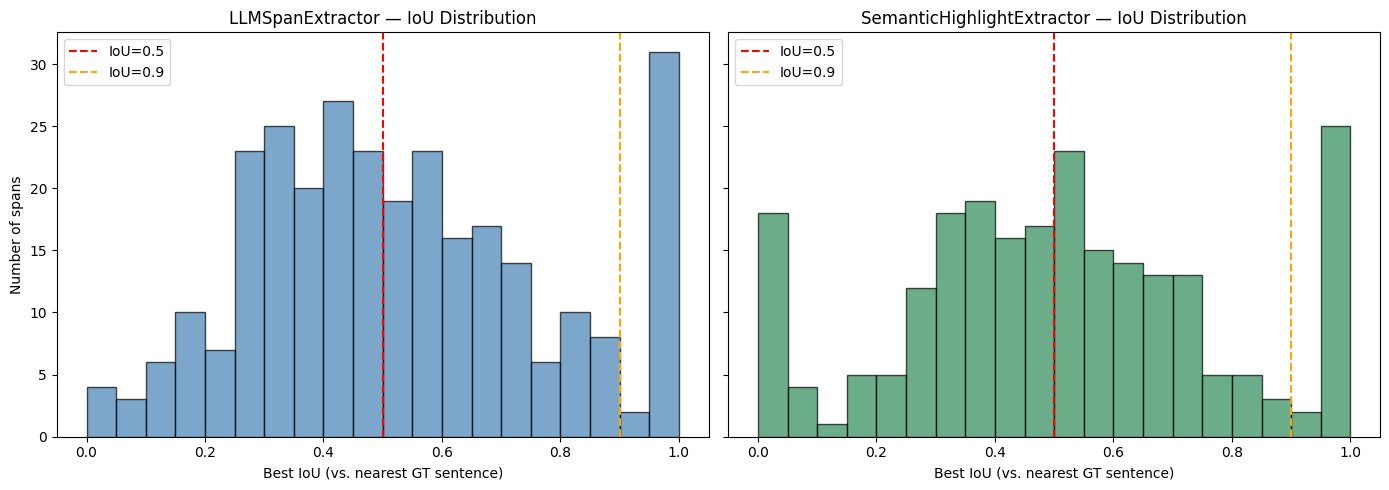

Saved: phase2_iou_distribution.png


In [5]:
# ============================================================================
# IoU Distribution Histogram
# ============================================================================
import json
import matplotlib.pyplot as plt
with open('phase2_results/llm_summary.json') as f:
    llm_ious = json.load(f)['ious']
with open('phase2_results/sem_summary.json') as f:
    sem_ious = json.load(f)['ious']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].hist(llm_ious, bins=20, range=(0, 1), edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('LLMSpanExtractor — IoU Distribution')
axes[0].set_xlabel('Best IoU (vs. nearest GT sentence)')
axes[0].set_ylabel('Number of spans')
axes[0].axvline(x=0.5, color='red', linestyle='--', label='IoU=0.5')
axes[0].axvline(x=0.9, color='orange', linestyle='--', label='IoU=0.9')
axes[0].legend()

axes[1].hist(sem_ious, bins=20, range=(0, 1), edgecolor='black', alpha=0.7, color='seagreen')
axes[1].set_title('SemanticHighlightExtractor — IoU Distribution')
axes[1].set_xlabel('Best IoU (vs. nearest GT sentence)')
axes[1].axvline(x=0.5, color='red', linestyle='--', label='IoU=0.5')
axes[1].axvline(x=0.9, color='orange', linestyle='--', label='IoU=0.9')
axes[1].legend()

plt.tight_layout()
plt.savefig('phase2_iou_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: phase2_iou_distribution.png")

In [12]:
# ============================================================================
# Save Final Results
# ============================================================================

final_results = {
    'llm_span_extractor': llm_summary,
    'semantic_highlight_extractor': sem_summary,
}

with open('phase2_results/phase2_final_results.json', 'w') as f:  # ← geändert
    json.dump(final_results, f, indent=2)

print("✅ Saved: phase2_final_results.json")
print("✅ Phase 2 complete!")

✅ Saved: phase2_final_results.json
✅ Phase 2 complete!


In [13]:
from verbatim_rag.extractors import SemanticHighlightExtractor
from types import SimpleNamespace
from tqdm import tqdm
from tabulate import tabulate
 
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_results = {}
 
dev_answerable = load_jsonl('../../data/clapnq_dev_answerable.jsonl')
 
for thr in thresholds:
    print(f"\n=== Threshold {thr} ===")
    extractor = SemanticHighlightExtractor(threshold=thr, output_mode="sentences")
    
    results = []
    for ex in tqdm(dev_answerable, desc=f"thr={thr}"):
        question = ex['input']
        passage = ex['passages'][0]
        passage_text = passage['text']
        search_results = [SimpleNamespace(text=passage_text)]
        
        try:
            spans_dict = extractor.extract_spans(question, search_results)
            extracted = list(spans_dict.values())[0] if spans_dict else []
        except:
            extracted = []
        
        results.append({
            'extracted_spans': extracted,
            'gt_sentences': ex['output'][0]['selected_sentences'],
            'all_sentences': passage['sentences'],
            'passage_text': passage_text,
        })
    
    summary, _ = evaluate_extractor(results, f"Semantic (thr={thr})")
    threshold_results[thr] = summary
    print(f"  Empty: {summary['n_empty_extractions']}, "
              f"Token F1: {summary['avg_token_f1']:.3f}, "
              f"IoU>=0.5: {summary['iou_proportions'][0.5]*100:.1f}%")

with open('phase2_results/threshold_results.json', 'w') as f:
    json.dump({str(k): v for k, v in threshold_results.items()}, f, indent=2)

# Print table
rows = []
for thr in thresholds:
    s = threshold_results[thr]
    rows.append([
        f"{thr:.1f}",
        s['n_empty_extractions'],
        f"{s['avg_token_precision']:.3f}",
        f"{s['avg_token_recall']:.3f}",
        f"{s['avg_token_f1']:.3f}",
        f"{s['iou_proportions'][0.5]*100:.1f}%",
        f"{s['avg_coverage']*100:.1f}%",
        f"{s['avg_over_extraction']*100:.1f}%",
    ])

headers = ["Threshold", "Empty", "Tok-P", "Tok-R", "Tok-F1", "IoU≥0.5", "Coverage", "Over-Extr."]
print(tabulate(rows, headers=headers, tablefmt="github"))
print("\n--- LaTeX ---")
print(tabulate(rows, headers=headers, tablefmt="latex_booktabs"))



=== Threshold 0.3 ===


Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 288.57it/s]


[OpenProvenceModel] Model inference time: 0.94s (1 blocks)


Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 82.84it/s]


[OpenProvenceModel] Model inference time: 0.90s (1 blocks)


...

[OpenProvenceModel] Model inference time: 0.75s (1 blocks)


Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 345.81it/s]


[OpenProvenceModel] Model inference time: 0.79s (1 blocks)


thr=0.7: 100%|██████████| 300/300 [08:10<00:00,  1.64s/it]

  Empty: 111, Token F1: 0.385, IoU>=0.5: 41.8%
|   Threshold |   Empty |   Tok-P |   Tok-R |   Tok-F1 | IoU≥0.5   | Coverage   | Over-Extr.   |
|-------------|---------|---------|---------|----------|-----------|------------|--------------|
|         0.3 |      36 |   0.766 |   0.544 |    0.594 | 51.1%     | 52.1%      | 14.0%        |
|         0.4 |      49 |   0.739 |   0.5   |    0.561 | 51.8%     | 48.0%      | 12.3%        |
|         0.5 |      67 |   0.699 |   0.439 |    0.507 | 50.6%     | 42.0%      | 10.5%        |
|         0.6 |      79 |   0.67  |   0.393 |    0.466 | 44.8%     | 37.6%      | 9.1%         |
|         0.7 |     111 |   0.577 |   0.314 |    0.385 | 41.8%     | 30.2%      | 7.2%         |

--- LaTeX ---
\begin{tabular}{rrrrrlll}
\toprule
   Threshold &   Empty &   Tok-P &   Tok-R &   Tok-F1 & IoU≥0.5   & Coverage   & Over-Extr.   \\
\midrule
         0.3 &      36 &   0.766 &   0.544 &    0.594 & 51.1\%     & 52.1\%      & 14.0\%        \\
         0.4 &    

In [9]:
from verbatim_rag.extractors import SemanticHighlightExtractor
from types import SimpleNamespace
from tqdm import tqdm
from tabulate import tabulate
 
thresholds_experiment_2 = [0.1, 0.2]
threshold_results_experiment_2 = {}
 
dev_answerable = load_jsonl('../../data/clapnq_dev_answerable.jsonl')
 
for thr in thresholds_experiment_2:
    print(f"\n=== Threshold {thr} ===")
    extractor = SemanticHighlightExtractor(threshold=thr, output_mode="sentences")
    
    results = []
    for ex in tqdm(dev_answerable, desc=f"thr={thr}"):
        question = ex['input']
        passage = ex['passages'][0]
        passage_text = passage['text']
        search_results = [SimpleNamespace(text=passage_text)]
        
        try:
            spans_dict = extractor.extract_spans(question, search_results)
            extracted = list(spans_dict.values())[0] if spans_dict else []
        except:
            extracted = []
        
        results.append({
            'extracted_spans': extracted,
            'gt_sentences': ex['output'][0]['selected_sentences'],
            'all_sentences': passage['sentences'],
            'passage_text': passage_text,
        })
    
    summary, _ = evaluate_extractor(results, f"Semantic (thr={thr})")
    threshold_results_experiment_2[thr] = summary
    print(f"  Empty: {summary['n_empty_extractions']}, "
              f"Token F1: {summary['avg_token_f1']:.3f}, "
              f"IoU>=0.5: {summary['iou_proportions'][0.5]*100:.1f}%")

with open('phase2_results/threshold_results_experiment_2.json', 'w') as f:
    json.dump({str(k): v for k, v in threshold_results_experiment_2.items()}, f, indent=2)

# Print table
rows = []
for thr in thresholds_experiment_2:
    s = threshold_results_experiment_2[thr]
    rows.append([
        f"{thr:.1f}",
        s['n_empty_extractions'],
        f"{s['avg_token_precision']:.3f}",
        f"{s['avg_token_recall']:.3f}",
        f"{s['avg_token_f1']:.3f}",
        f"{s['iou_proportions'][0.5]*100:.1f}%",
        f"{s['avg_coverage']*100:.1f}%",
        f"{s['avg_over_extraction']*100:.1f}%",
    ])

headers = ["Threshold", "Empty", "Tok-P", "Tok-R", "Tok-F1", "IoU≥0.5", "Coverage", "Over-Extr."]
print(tabulate(rows, headers=headers, tablefmt="github"))
print("\n--- LaTeX ---")
print(tabulate(rows, headers=headers, tablefmt="latex_booktabs"))



=== Threshold 0.1 ===


Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 60.98it/s]


[OpenProvenceModel] Model inference time: 5.13s (1 blocks)


Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 31.62it/s]


[OpenProvenceModel] Model inference time: 5.94s (1 blocks)


...

[OpenProvenceModel] Model inference time: 0.75s (1 blocks)


Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 231.93it/s]


[OpenProvenceModel] Model inference time: 0.80s (1 blocks)


thr=0.2: 100%|██████████| 300/300 [08:26<00:00,  1.69s/it]

  Empty: 22, Token F1: 0.644, IoU>=0.5: 54.0%
|   Threshold |   Empty |   Tok-P |   Tok-R |   Tok-F1 | IoU≥0.5   | Coverage   | Over-Extr.   |
|-------------|---------|---------|---------|----------|-----------|------------|--------------|
|         0.1 |       8 |   0.794 |   0.734 |    0.708 | 58.2%     | 71.2%      | 19.7%        |
|         0.2 |      22 |   0.791 |   0.613 |    0.644 | 54.0%     | 58.9%      | 15.9%        |

--- LaTeX ---
\begin{tabular}{rrrrrlll}
\toprule
   Threshold &   Empty &   Tok-P &   Tok-R &   Tok-F1 & IoU≥0.5   & Coverage   & Over-Extr.   \\
\midrule
         0.1 &       8 &   0.794 &   0.734 &    0.708 & 58.2\%     & 71.2\%      & 19.7\%        \\
         0.2 &      22 &   0.791 &   0.613 &    0.644 & 54.0\%     & 58.9\%      & 15.9\%        \\
\bottomrule
\end{tabular}


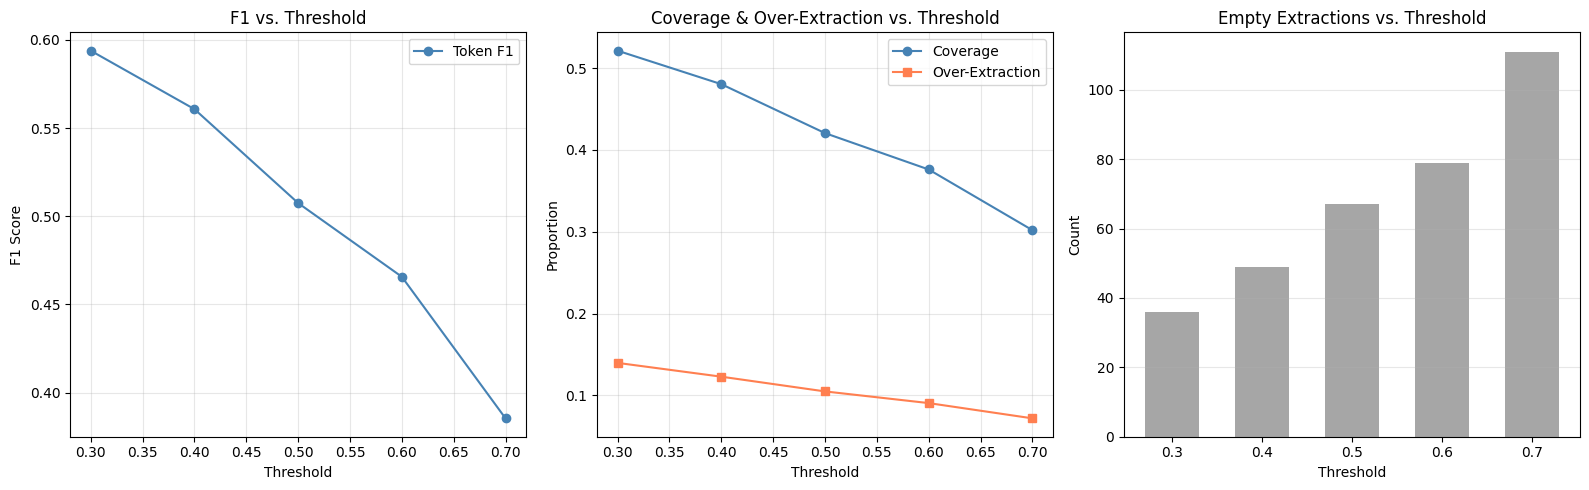

Saved: phase2_threshold_sensitivity.png


In [6]:

with open('phase2_results/threshold_results.json') as f:
    threshold_results = {float(k): v for k, v in json.load(f).items()}
    for v in threshold_results.values():
        v['iou_proportions'] = {float(k2): v2 for k2, v2 in v['iou_proportions'].items()}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
thrs = sorted(threshold_results.keys())
tok_f1 = [threshold_results[t]['avg_token_f1'] for t in thrs]
empty = [threshold_results[t]['n_empty_extractions'] for t in thrs]
cov = [threshold_results[t]['avg_coverage'] for t in thrs]
overex = [threshold_results[t]['avg_over_extraction'] for t in thrs]
 
axes[0].plot(thrs, tok_f1, 'o-', label='Token F1', color='steelblue')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('F1 vs. Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
 
axes[1].plot(thrs, cov, 'o-', label='Coverage', color='steelblue')
axes[1].plot(thrs, overex, 's-', label='Over-Extraction', color='coral')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Proportion')
axes[1].set_title('Coverage & Over-Extraction vs. Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
 
axes[2].bar(thrs, empty, width=0.06, color='gray', alpha=0.7)
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('Count')
axes[2].set_title('Empty Extractions vs. Threshold')
axes[2].grid(True, alpha=0.3, axis='y')
 
plt.tight_layout()
plt.savefig('phase2_threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: phase2_threshold_sensitivity.png")

In [10]:
from tabulate import tabulate
import json

# Lade alte Ergebnisse
with open('phase2_results/threshold_results.json') as f:
    threshold_results = {float(k): v for k, v in json.load(f).items()}
    for v in threshold_results.values():
        v['iou_proportions'] = {float(k2): v2 for k2, v2 in v['iou_proportions'].items()}

# Lade neue Ergebnisse und füge zusammen
with open('phase2_results/threshold_results_experiment_2.json') as f:
    new_results = {float(k): v for k, v in json.load(f).items()}
    for v in new_results.values():
        v['iou_proportions'] = {float(k2): v2 for k2, v2 in v['iou_proportions'].items()}

threshold_results.update(new_results)

rows = []
for thr in sorted(threshold_results.keys()):
    s = threshold_results[thr]
    rows.append([
        f"{thr:.1f}",
        s['n_empty_extractions'],
        f"{s['mean_iou']:.3f}",
        f"{s['avg_token_precision']:.3f}",
        f"{s['avg_token_recall']:.3f}",
        f"{s['avg_token_f1']:.3f}",
        f"{s['iou_proportions'][0.5]*100:.1f}%",
        f"{s['avg_coverage']*100:.1f}%",
        f"{s['avg_over_extraction']*100:.1f}%",
    ])

headers = ["Threshold", "Empty", "Mean IoU", "Tok-P", "Tok-R", 
           "Tok-F1", "IoU≥0.5", "Coverage", "Over-Extr."]
print(tabulate(rows, headers=headers, tablefmt="github"))
print("\n--- LaTeX ---")
print(tabulate(rows, headers=headers, tablefmt="latex_booktabs"))

|   Threshold |   Empty |   Mean IoU |   Tok-P |   Tok-R |   Tok-F1 | IoU≥0.5   | Coverage   | Over-Extr.   |
|-------------|---------|------------|---------|---------|----------|-----------|------------|--------------|
|         0.1 |       8 |      0.592 |   0.794 |   0.734 |    0.708 | 58.2%     | 71.2%      | 19.7%        |
|         0.2 |      22 |      0.548 |   0.791 |   0.613 |    0.644 | 54.0%     | 58.9%      | 15.9%        |
|         0.3 |      36 |      0.528 |   0.766 |   0.544 |    0.594 | 51.1%     | 52.1%      | 14.0%        |
|         0.4 |      49 |      0.528 |   0.739 |   0.5   |    0.561 | 51.8%     | 48.0%      | 12.3%        |
|         0.5 |      67 |      0.508 |   0.699 |   0.439 |    0.507 | 50.6%     | 42.0%      | 10.5%        |
|         0.6 |      79 |      0.482 |   0.67  |   0.393 |    0.466 | 44.8%     | 37.6%      | 9.1%         |
|         0.7 |     111 |      0.46  |   0.577 |   0.314 |    0.385 | 41.8%     | 30.2%      | 7.2%         |

--- LaTeX

In [13]:

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

from types import SimpleNamespace
from tabulate import tabulate

unanswerable_rates = {}

for thr in thresholds:
    extractor = SemanticHighlightExtractor(threshold=thr, output_mode="sentences")
    n_false = 0
    
    for ex in dev_unanswerable:
        search_results = [SimpleNamespace(text=ex['passages'][0]['text'])]
        
        try:
            spans = extractor.extract_spans(ex['input'], search_results)
            extracted = list(spans.values())[0] if spans else []
        except:
            extracted = []
        
        if extracted:
            n_false += 1
    
    unanswerable_rates[thr] = n_false
    print(f"thr={thr} done")

with open('phase2_results/unanswerable_rates.json', 'w') as f:
    json.dump({str(k): v for k, v in unanswerable_rates.items()}, f, indent=2)

# =========================
# LaTeX Tabelle erzeugen
# =========================

table = []
for thr in sorted(unanswerable_rates.keys()):
    n_false = unanswerable_rates[thr]
    n_total = len(dev_unanswerable)
    n_correct = n_total - n_false
    
    table.append([
        thr,
        f"{n_correct}/{n_total}",
        f"{n_false}/{n_total}"
    ])

print("\nLaTeX Table:\n")
print(tabulate(
    table,
    headers=["Threshold", "Abstention", "False Extract"],
    tablefmt="latex_booktabs"
))

Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 58.85it/s]


[OpenProvenceModel] Model inference time: 3.41s (1 blocks)


Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 32.88it/s]


[OpenProvenceModel] Model inference time: 2.61s (1 blocks)


Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 64.72it/s]


...

[OpenProvenceModel] Model inference time: 0.92s (1 blocks)


Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 81.08it/s]


[OpenProvenceModel] Model inference time: 1.37s (1 blocks)


Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 83.12it/s]


[OpenProvenceModel] Model inference time: 1.43s (1 blocks)
thr=0.7 done

LaTeX Table:

\begin{tabular}{rll}
\toprule
   Threshold & Abstention   & False Extract   \\
\midrule
         0.3 & 250/300      & 50/300          \\
         0.4 & 258/300      & 42/300          \\
         0.5 & 274/300      & 26/300          \\
         0.6 & 282/300      & 18/300          \\
         0.7 & 285/300      & 15/300          \\
\bottomrule
\end{tabular}


In [14]:
import json
with open('phase2_results/threshold_results.json') as f:
    threshold_results = {float(k): v for k, v in json.load(f).items()}
    for v in threshold_results.values():
        v['iou_proportions'] = {float(k2): v2 for k2, v2 in v['iou_proportions'].items()}


from tabulate import tabulate

rows = []
for thr in sorted(threshold_results.keys()):
    s = threshold_results[thr]
    rows.append([
        f"{thr:.1f}",
        s['n_empty_extractions'],
        f"{s['avg_token_precision']:.3f}",
        f"{s['avg_token_recall']:.3f}",
        f"{s['avg_token_f1']:.3f}",
        f"{s['iou_proportions'][0.5]*100:.1f}%",
        f"{s['avg_coverage']*100:.1f}%",
        f"{s['avg_over_extraction']*100:.1f}%",
    ])

headers = ["Threshold", "Empty", "Tok-P", "Tok-R", "Tok-F1", "IoU≥0.5", "Coverage", "Over-Extr."]
print(tabulate(rows, headers=headers, tablefmt="github"))
print("\n--- LaTeX ---")
print(tabulate(rows, headers=headers, tablefmt="latex_booktabs"))


|   Threshold |   Empty |   Tok-P |   Tok-R |   Tok-F1 | IoU≥0.5   | Coverage   | Over-Extr.   |
|-------------|---------|---------|---------|----------|-----------|------------|--------------|
|         0.3 |      36 |   0.766 |   0.544 |    0.594 | 51.1%     | 52.1%      | 14.0%        |
|         0.4 |      49 |   0.739 |   0.5   |    0.561 | 51.8%     | 48.0%      | 12.3%        |
|         0.5 |      67 |   0.699 |   0.439 |    0.507 | 50.6%     | 42.0%      | 10.5%        |
|         0.6 |      79 |   0.67  |   0.393 |    0.466 | 44.8%     | 37.6%      | 9.1%         |
|         0.7 |     111 |   0.577 |   0.314 |    0.385 | 41.8%     | 30.2%      | 7.2%         |

--- LaTeX ---
\begin{tabular}{rrrrrlll}
\toprule
   Threshold &   Empty &   Tok-P &   Tok-R &   Tok-F1 & IoU≥0.5   & Coverage   & Over-Extr.   \\
\midrule
         0.3 &      36 &   0.766 &   0.544 &    0.594 & 51.1\%     & 52.1\%      & 14.0\%        \\
         0.4 &      49 &   0.739 &   0.5   &    0.561 & 51.8\%   

In [15]:
# Span-mode evaluation (answerable + unanswerable)
from verbatim_rag.extractors import SemanticHighlightExtractor
from types import SimpleNamespace

span_extractor = SemanticHighlightExtractor(threshold=0.5, output_mode="spans")

# Answerable
span_results_answerable = []
for ex in dev_answerable:
    search_results = [SimpleNamespace(text=ex['passages'][0]['text'])]
    try:
        spans = span_extractor.extract_spans(ex['input'], search_results)
        extracted = list(spans.values())[0] if spans else []
    except:
        extracted = []
    span_results_answerable.append({
        'extracted_spans': extracted,
        'gt_sentences': ex['output'][0]['selected_sentences'],
        'all_sentences': ex['passages'][0]['sentences'],
        'passage_text': ex['passages'][0]['text'],
    })
print(f"Answerable done: {len(span_results_answerable)}")

# Unanswerable
span_unanswerable_false = 0
for ex in dev_unanswerable:
    search_results = [SimpleNamespace(text=ex['passages'][0]['text'])]
    try:
        spans = span_extractor.extract_spans(ex['input'], search_results)
        extracted = list(spans.values())[0] if spans else []
    except:
        extracted = []
    if extracted:
        span_unanswerable_false += 1
print(f"Unanswerable done: false extractions = {span_unanswerable_false}/{len(dev_unanswerable)}")

Answerable done: 300


Length mismatch probs=4083 tokens=4096


Unanswerable done: false extractions = 27/300


In [ ]:
span_summary, span_ious = evaluate_extractor(span_results_answerable, "SemanticHighlight (spans)")

with open('phase2_results/span_summary.json', 'w') as f:
    json.dump({'summary': span_summary, 'ious': span_ious}, f, indent=2)
with open('phase2_results/unanswerable_rates.json', 'w') as f:
    json.dump({str(k): v for k, v in unanswerable_rates.items()}, f, indent=2)

In [17]:


from tabulate import tabulate
with open('phase2_results/unanswerable_rates.json') as f:
    unanswerable_rates = {float(k): v for k, v in json.load(f).items()}

rows = []
for thr in sorted(unanswerable_rates.keys()):
    n_false = unanswerable_rates[thr]
    n_correct = len(dev_unanswerable) - n_false
    rows.append([
        f"{thr:.1f}",
        f"{n_correct}/{len(dev_unanswerable)}",
        f"{n_false}/{len(dev_unanswerable)}",
    ])

headers = ["Extractor", "Unanswerable Accuracy", "False Extractions"]
print(tabulate(rows, headers=headers, tablefmt="github"))
print("\n--- LaTeX ---")
print(tabulate(rows, headers=headers, tablefmt="latex_booktabs"))

|   Extractor | Unanswerable Accuracy   | False Extractions   |
|-------------|-------------------------|---------------------|
|         0.3 | 250/300                 | 50/300              |
|         0.4 | 258/300                 | 42/300              |
|         0.5 | 274/300                 | 26/300              |
|         0.6 | 282/300                 | 18/300              |
|         0.7 | 285/300                 | 15/300              |

--- LaTeX ---
\begin{tabular}{rll}
\toprule
   Extractor & Unanswerable Accuracy   & False Extractions   \\
\midrule
         0.3 & 250/300                 & 50/300              \\
         0.4 & 258/300                 & 42/300              \\
         0.5 & 274/300                 & 26/300              \\
         0.6 & 282/300                 & 18/300              \\
         0.7 & 285/300                 & 15/300              \\
\bottomrule
\end{tabular}


In [11]:

thresholds_experiment_2 = [0.1, 0.2]

from types import SimpleNamespace
from tabulate import tabulate

unanswerable_rates_experiment_2 = {}

for thr in  thresholds_experiment_2:
    extractor = SemanticHighlightExtractor(threshold=thr, output_mode="sentences")
    n_false = 0
    
    for ex in dev_unanswerable:
        search_results = [SimpleNamespace(text=ex['passages'][0]['text'])]
        
        try:
            spans = extractor.extract_spans(ex['input'], search_results)
            extracted = list(spans.values())[0] if spans else []
        except:
            extracted = []
        
        if extracted:
            n_false += 1
    
    unanswerable_rates_experiment_2[thr] = n_false
    print(f"thr={thr} done")

with open('phase2_results/unanswerable_rates_experiment_2.json', 'w') as f:
    json.dump({str(k): v for k, v in unanswerable_rates_experiment_2.items()}, f, indent=2)

# =========================
# LaTeX Tabelle erzeugen
# =========================

table = []
for thr in sorted(unanswerable_rates_experiment_2.keys()):
    n_false = unanswerable_rates_experiment_2[thr]
    n_total = len(dev_unanswerable)
    n_correct = n_total - n_false
    
    table.append([
        thr,
        f"{n_correct}/{n_total}",
        f"{n_false}/{n_total}"
    ])

print("\nLaTeX Table:\n")
print(tabulate(
    table,
    headers=["Threshold", "Abstention", "False Extract"],
    tablefmt="latex_booktabs"
))

Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 95.06it/s]


[OpenProvenceModel] Model inference time: 10.06s (1 blocks)


Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 36.77it/s]


[OpenProvenceModel] Model inference time: 0.65s (1 blocks)


Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 106.25it/s]


...

[OpenProvenceModel] Model inference time: 0.95s (1 blocks)


Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 30.88it/s]


[OpenProvenceModel] Model inference time: 1.27s (1 blocks)


Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 29.44it/s]


[OpenProvenceModel] Model inference time: 1.50s (1 blocks)
thr=0.2 done

LaTeX Table:

\begin{tabular}{rll}
\toprule
   Threshold & Abstention   & False Extract   \\
\midrule
         0.1 & 196/300      & 104/300         \\
         0.2 & 232/300      & 68/300          \\
\bottomrule
\end{tabular}


In [12]:
from tabulate import tabulate
import json

# Lade alte Ergebnisse
with open('phase2_results/unanswerable_rates.json') as f:
    unanswerable_rates = {float(k): v for k, v in json.load(f).items()}

# Lade neue Ergebnisse und füge zusammen
with open('phase2_results/unanswerable_rates_experiment_2.json') as f:
    new_rates = {float(k): v for k, v in json.load(f).items()}

unanswerable_rates.update(new_rates)

rows = []
for thr in sorted(unanswerable_rates.keys()):
    n_false = unanswerable_rates[thr]
    n_correct = len(dev_unanswerable) - n_false
    rows.append([
        f"{thr:.1f}",
        f"{n_correct}/{len(dev_unanswerable)}",
        f"{n_false}/{len(dev_unanswerable)}",
    ])

headers = ["Threshold", "Unanswerable Accuracy", "False Extractions"]
print(tabulate(rows, headers=headers, tablefmt="github"))
print("\n--- LaTeX ---")
print(tabulate(rows, headers=headers, tablefmt="latex_booktabs"))

|   Threshold | Unanswerable Accuracy   | False Extractions   |
|-------------|-------------------------|---------------------|
|         0.1 | 196/300                 | 104/300             |
|         0.2 | 232/300                 | 68/300              |
|         0.3 | 250/300                 | 50/300              |
|         0.4 | 258/300                 | 42/300              |
|         0.5 | 274/300                 | 26/300              |
|         0.6 | 282/300                 | 18/300              |
|         0.7 | 285/300                 | 15/300              |

--- LaTeX ---
\begin{tabular}{rll}
\toprule
   Threshold & Unanswerable Accuracy   & False Extractions   \\
\midrule
         0.1 & 196/300                 & 104/300             \\
         0.2 & 232/300                 & 68/300              \\
         0.3 & 250/300                 & 50/300              \\
         0.4 & 258/300                 & 42/300              \\
         0.5 & 274/300                 & 26/300   